In [197]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid

Se importan tablas

In [198]:
clusters = pd.read_csv('../data/processed/clusters.csv')
members = pd.read_csv('../data/processed/members.csv')

### Función que calcula las distancias angulares

In [199]:
def angular_distances(ra0, dec0, ras, decs):
    ra0 = np.radians(ra0)
    dec0 = np.radians(dec0)
    ras = np.radians(ras)
    decs = np.radians(decs)

    delta_ra = ras - ra0
    delta_dec = decs - dec0

    a = np.sin(delta_dec / 2)**2 + np.cos(dec0) * np.cos(decs) * np.sin(delta_ra / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return c

### Función que proyecta al plano tangente

In [200]:
def tangent_plane_projection(ras, decs, ra0, dec0, d0):
    ras = np.radians(ras)
    decs = np.radians(decs)

    ra0 = np.radians(ra0)
    dec0 = np.radians(dec0)

    delta_ras = ras - ra0

    den = (np.sin(dec0) * np.sin(decs) + 
           np.cos(dec0) * np.cos(decs) * np.cos(delta_ras))
    
    xi = (np.cos(decs) * np.sin(delta_ras)) / den

    eta = (np.cos(dec0) * np.sin(decs) - 
           np.sin(dec0) * np.cos(decs) * np.cos(delta_ras)) / den
    
    X = xi * d0
    Y = eta * d0

    return X, Y

### Función de densidad proyectada (King 1962)

In [201]:
def sigma(r, rc, rt, k):
    term1 = 1 / (1 + (r / rc)**2)**0.5
    term2 = 1 / (1 + (rt / rc)**2)**0.5

    sigma = k * (term1 - term2)**2
    sigma[r > rt] = 0
    
    return sigma

### Función de densidad volumétrica (King 1962)

In [202]:
def rho(r, rc, rt, k):
  values = np.zeros_like(r, dtype=float)

  mask = r < rt
  r_valid = r[mask]

  w = np.sqrt((1 + (r_valid/rc)**2) / (1 + (rt/rc)**2))

  C = k / (np.pi * rc * (1 + (rt/rc)**2)**1.5)

  term1 = 1.0 / (w**2)
  term2 = (1.0 / w) * np.arccos(w) - np.sqrt(1 - w**2)

  values[mask] = C * term1 * term2
  
  return values

### Función de ajuste de densidad proyectada

In [203]:
def fit_projected_density(R, num_bins=30):
    counts, bin_edges = np.histogram(R, bins=num_bins)
    
    r_mid = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    areas = np.pi * (bin_edges[1:]**2 - bin_edges[:-1]**2)

    sigma_obs = counts / areas

    k_guess = np.max(sigma_obs)
    rc_guess = np.median(R) * 0.5
    rt_guess = np.max(R)

    p0 = [rc_guess, rt_guess, k_guess]
    popt, _ = curve_fit(sigma, r_mid, sigma_obs, p0=p0, bounds=(0, np.inf))

    return popt

### Función de *rejection sampling*

In [204]:
def rejection_sampling(R, rc, rt, k):
    Z_samples = np.zeros_like(R, dtype=float)

    mask = R < rt
    R_valid = R[mask]

    N = len(R_valid)
    Z_valid = np.zeros(N)

    Z_max = np.sqrt(rt**2 - R_valid**2)

    rho_max = rho(R_valid, rc, rt, k)

    unaccepted = np.ones(N, dtype=bool)

    while np.any(unaccepted):
        indices = np.nonzero(unaccepted)[0]

        Z_cand = np.random.uniform(-Z_max[indices], Z_max[indices])

        r_cand = np.sqrt(R_valid[indices]**2 + Z_cand**2)

        rho_cand = rho(r_cand, rc, rt, k)

        u = np.random.uniform(0, rho_max[indices])

        accept = u <= rho_cand

        Z_valid[indices[accept]] = Z_cand[accept]
        unaccepted[indices[accept]] = False

    Z_samples[mask] = Z_valid

    return Z_samples

nombres: King_11, NGC_2437 (este solo tiene 1 en Z=0), NGC_1912, NGC_6475

## Análisis estadístico del cúmulo King 11

Selección de miembros del cúmulo.

In [205]:
king_11 = clusters[clusters['Name'] == 'King_11']
king_11_members = members[members['Name'] == 'King_11']

Se seleccionan los valores de la declinación, ascensión recta y distancia al punto más denso del cúmulo y de los miembros de este.

In [206]:
ra0_king_11 = king_11['RA_ICRS'].values[0]
dec0_king_11 = king_11['DE_ICRS'].values[0]
d0_king_11 = king_11['dist50'].values[0]

ras_king_11 = king_11_members['RA_ICRS'].values
decs_king_11 = king_11_members['DE_ICRS'].values
ds_king_11 = king_11_members['r_med_photogeo'].values

Se calculan las distancias angulares y las distancias proyectadas en el plano.

In [207]:
ang_dist_king_11 = angular_distances(ra0_king_11, dec0_king_11, ras_king_11, decs_king_11)
Rs_king_11 = d0_king_11 * np.tan(ang_dist_king_11)

Se realiza el ajuste del perfil de densidad proyectada para encontrar $r_c$, $r_t$ y $k$.

In [208]:
rc_king_11, rt_king_11, k_king_11 = fit_projected_density(Rs_king_11)

Se realiza la proyección al plano tangente.

In [209]:
X_king_11, Y_king_11 = tangent_plane_projection(ras_king_11, decs_king_11, ra0_king_11, dec0_king_11, d0_king_11)

Configuraciones de la simulación.

In [210]:
m_realization = 10000
N_stars = len(Rs_king_11)

Se inicializa la matriz de N filas (estrellas) por m columnas (realizaciones).

In [211]:
Z_matrix_king_11 = np.zeros((N_stars, m_realization))

Se calculan las m realizaciones de Monte Carlo.

In [212]:
for j in range(m_realization):
    Z_matrix_king_11[:, j] = rejection_sampling(Rs_king_11, rc_king_11, rt_king_11, k_king_11)

Se filtran las estrellas que están dentro del radio de marea.

In [213]:
mask = Rs_king_11 < rt_king_11
Rs_king_11_valid = Rs_king_11[mask]
Z_matrix_king_11_valid = Z_matrix_king_11[mask, :]

### Gráficas de Probabilidad Marginal $P(Z)$ total

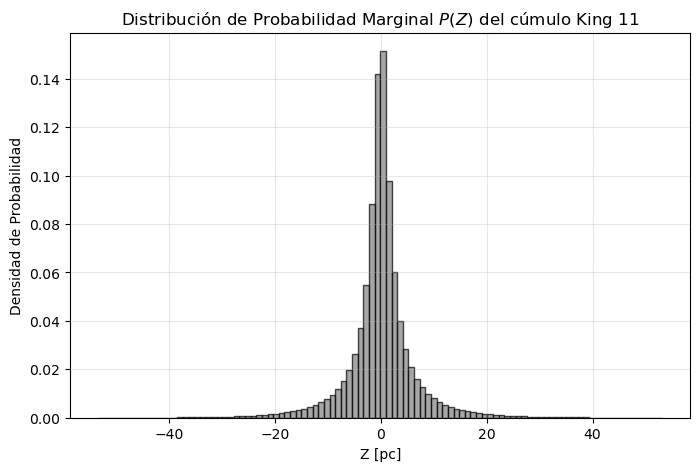

In [214]:
plt.figure(figsize=(8, 5))

Z_total = Z_matrix_king_11_valid.flatten()

plt.hist(Z_total, bins=100, density=True, color='gray', alpha=0.7, edgecolor='black')
plt.title('Distribución de Probabilidad Marginal $P(Z)$ del cúmulo King 11')
plt.xlabel('Z [pc]')
plt.ylabel('Densidad de Probabilidad')
plt.grid(True, alpha=0.3)
plt.show()

### Gráfica de Probabilidad Condicional $P(Z\ |\ X, Y)$

Para esta gráfica, se seleccionan 4 estrellas a diferentes distancias del cetro para comparar.

* Estrella 1: Muy cerca del núcleo ($R \thicksim$ 0).
* Estrella 2: Cerca del radio del núcleo ($R \thicksim r_c$).
* Estrella 3: En la zona intermedia.
* Estrella 4: Muy cerca del radio de marea ($R \thicksim r_t$).

Se selecciona los índices de las estrellas en cada rango.

In [215]:
idx = [
    np.argmin(np.abs(Rs_king_11_valid - 0.1)),
    np.argmin(np.abs(Rs_king_11_valid - rc_king_11)),
    np.argmin(np.abs(Rs_king_11_valid - rt_king_11/2)),
    np.argmin(np.abs(Rs_king_11_valid - 0.95*rt_king_11))
]

In [216]:
colors = ['blue', 'green', 'orange', 'red']
labels = [
    f'Estrella en Núcleo (R={Rs_king_11_valid[idx[0]]:.2f} pc)',
    f'Estrella en $r_c$ (R={Rs_king_11_valid[idx[1]]:.2f} pc)',
    f'Estrella en Intermedia (R={Rs_king_11_valid[idx[2]]:.2f} pc)',
    f'Estrella en Borde (R={Rs_king_11_valid[idx[3]]:.2f} pc)'
]

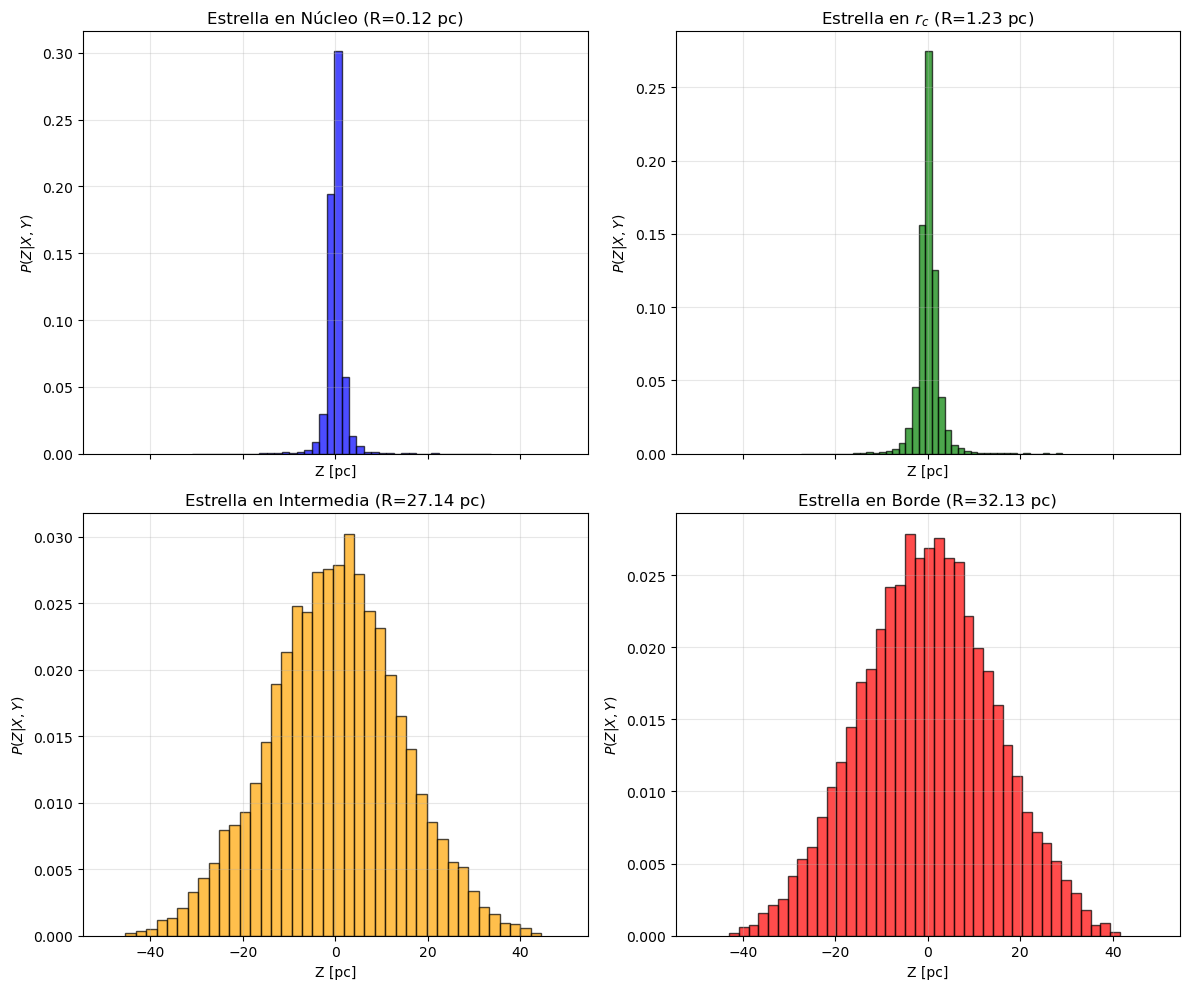

In [217]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axs = axs.flatten()

for i, idx_star in enumerate(idx):
    Z_star = Z_matrix_king_11_valid[idx_star, :]
    
    axs[i].hist(Z_star, bins=40, density=True, color=colors[i], alpha=0.7, edgecolor='black')
    axs[i].set_title(labels[i])
    axs[i].set_xlabel('Z [pc]')
    axs[i].set_ylabel('$P(Z | X, Y)$')
    axs[i].grid(True, alpha=0.3)

    axs[i].set_xlim(-rt_king_11, rt_king_11)

plt.tight_layout()
plt.show()

## Análisis estadístico del cúmulo NGC 1912

Selección de miembros del cúmulo.

In [218]:
ngc_1912 = clusters[clusters['Name'] == 'NGC_1912']
ngc_1912_members = members[members['Name'] == 'NGC_1912']

Se seleccionan los valores de la declinación, ascensión recta y distancia al punto más denso del cúmulo y de los miembros de este.

In [219]:
ra0_ngc_1912 = ngc_1912['RA_ICRS'].values[0]
dec0_ngc_1912 = ngc_1912['DE_ICRS'].values[0]
d0_ngc_1912 = ngc_1912['dist50'].values[0]

ras_ngc_1912 = ngc_1912_members['RA_ICRS'].values
decs_ngc_1912 = ngc_1912_members['DE_ICRS'].values
ds_ngc_1912 = ngc_1912_members['r_med_photogeo'].values

Se calculan las distancias angulares y las distancias proyectadas en el plano.

In [220]:
ang_dist_ngc_1912 = angular_distances(ra0_ngc_1912, dec0_ngc_1912, ras_ngc_1912, decs_ngc_1912)
Rs_ngc_1912 = d0_ngc_1912 * np.tan(ang_dist_ngc_1912)

Se realiza el ajuste del perfil de densidad proyectada para encontrar $r_c$, $r_t$ y $k$.

In [221]:
rc_ngc_1912, rt_ngc_1912, k_ngc_1912 = fit_projected_density(Rs_ngc_1912)

Se realiza la proyección al plano tangente.

In [222]:
X_ngc_1912, Y_ngc_1912 = tangent_plane_projection(ras_ngc_1912, decs_ngc_1912, ra0_ngc_1912, dec0_ngc_1912, d0_ngc_1912)

Configuraciones de la simulación.

In [223]:
m_realization = 10000
N_stars = len(Rs_ngc_1912)

Se inicializa la matriz de N filas (estrellas) por m columnas (realizaciones).

In [224]:
Z_matrix_ngc_1912 = np.zeros((N_stars, m_realization))

Se calculan las m realizaciones de Monte Carlo.

In [225]:
for j in range(m_realization):
    Z_matrix_ngc_1912[:, j] = rejection_sampling(Rs_ngc_1912, rc_ngc_1912, rt_ngc_1912, k_ngc_1912)

Se filtran las estrellas que están dentro del radio de marea.

In [226]:
mask = Rs_ngc_1912 < rt_ngc_1912
Rs_valid_ngc_1912 = Rs_ngc_1912[mask]
Z_matrix_valid_ngc_1912 = Z_matrix_ngc_1912[mask, :]

### Gráficas de Probabilidad Marginal $P(Z)$ total

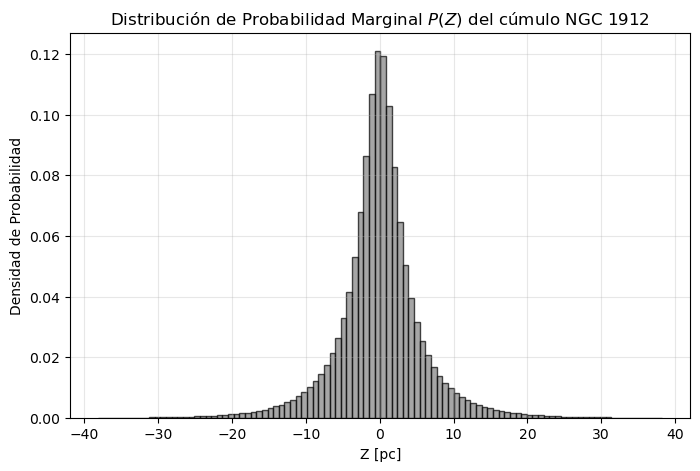

In [227]:
plt.figure(figsize=(8, 5))

Z_total = Z_matrix_valid_ngc_1912.flatten()

plt.hist(Z_total, bins=100, density=True, color='gray', alpha=0.7, edgecolor='black')
plt.title('Distribución de Probabilidad Marginal $P(Z)$ del cúmulo NGC 1912')
plt.xlabel('Z [pc]')
plt.ylabel('Densidad de Probabilidad')
plt.grid(True, alpha=0.3)
plt.show()

### Gráfica de Probabilidad Condicional $P(Z\ |\ X, Y)$

Se selecciona los índices de las estrellas en cada rango.

In [228]:
idx = [
    np.argmin(np.abs(Rs_valid_ngc_1912 - 0.1)),
    np.argmin(np.abs(Rs_valid_ngc_1912 - rc_ngc_1912)),
    np.argmin(np.abs(Rs_valid_ngc_1912 - rt_ngc_1912/2)),
    np.argmin(np.abs(Rs_valid_ngc_1912 - 0.95*rt_ngc_1912))
]

In [229]:
colors = ['blue', 'green', 'orange', 'red']
labels = [
    f'Estrella en Núcleo (R={Rs_valid_ngc_1912[idx[0]]:.2f} pc)',
    f'Estrella en $r_c$ (R={Rs_valid_ngc_1912[idx[1]]:.2f} pc)',
    f'Estrella en Intermedia (R={Rs_valid_ngc_1912[idx[2]]:.2f} pc)',
    f'Estrella en Borde (R={Rs_valid_ngc_1912[idx[3]]:.2f} pc)'
]

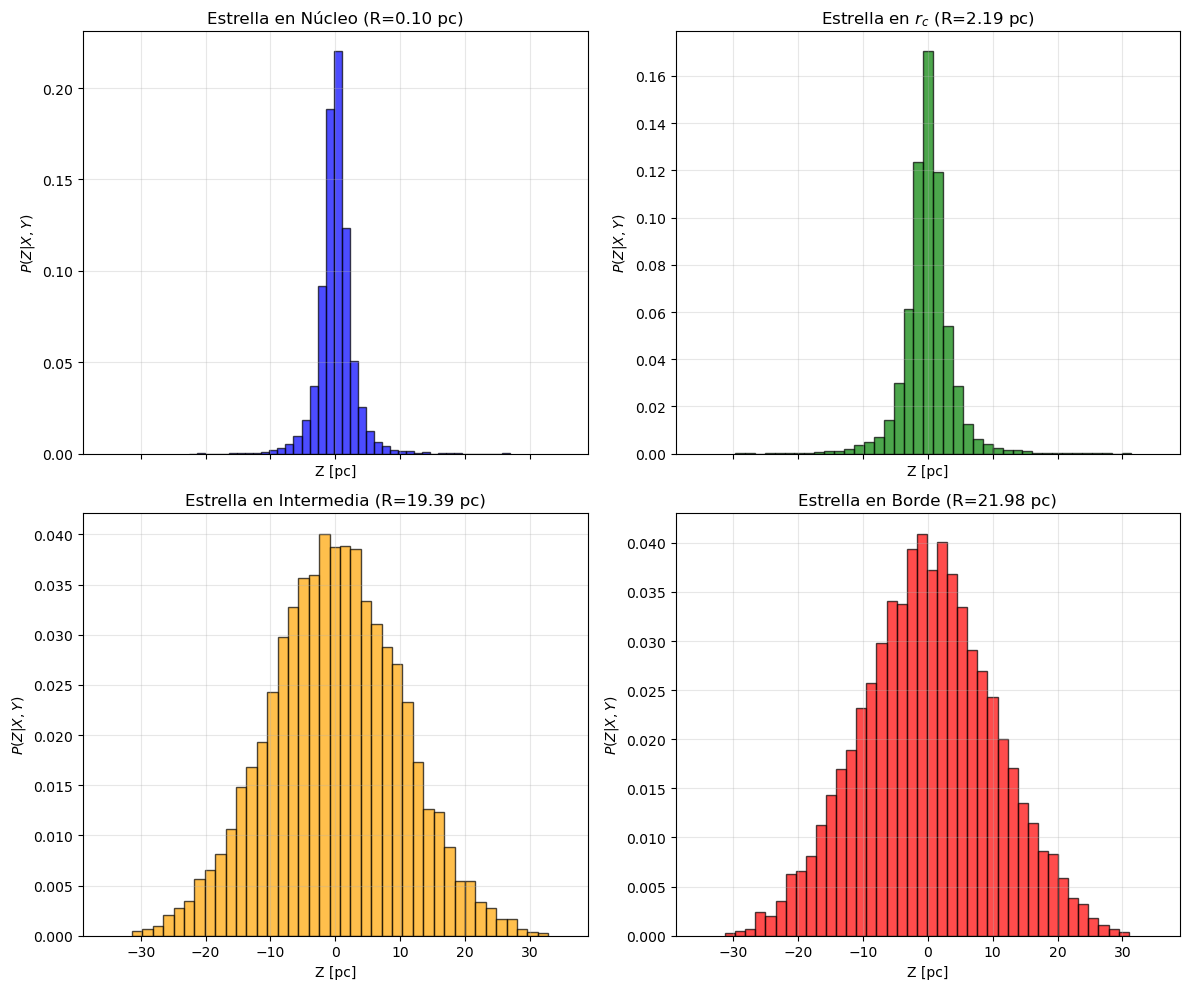

In [230]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axs = axs.flatten()

for i, idx_star in enumerate(idx):
    Z_star = Z_matrix_valid_ngc_1912[idx_star, :]
    
    axs[i].hist(Z_star, bins=40, density=True, color=colors[i], alpha=0.7, edgecolor='black')
    axs[i].set_title(labels[i])
    axs[i].set_xlabel('Z [pc]')
    axs[i].set_ylabel('$P(Z | X, Y)$')
    axs[i].grid(True, alpha=0.3)

    axs[i].set_xlim(-rt_ngc_1912, rt_ngc_1912)

plt.tight_layout()
plt.show()

## Análisis estadístico del cúmulo NGC 6475

Selección de miembros del cúmulo.

In [231]:
ngc_6475 = clusters[clusters['Name'] == 'NGC_6475']
ngc_6475_members = members[members['Name'] == 'NGC_6475']

Se seleccionan los valores de la declinación, ascensión recta y distancia al punto más denso del cúmulo y de los miembros de este.

In [232]:
ra0_ngc_6475 = ngc_6475['RA_ICRS'].values[0]
dec0_ngc_6475 = ngc_6475['DE_ICRS'].values[0]
d0_ngc_6475 = ngc_6475['dist50'].values[0]

ras_ngc_6475 = ngc_6475_members['RA_ICRS'].values
decs_ngc_6475 = ngc_6475_members['DE_ICRS'].values
ds_ngc_6475 = ngc_6475_members['r_med_photogeo'].values

Se calculan las distancias angulares y las distancias proyectadas en el plano.

In [233]:
ang_dist_ngc_6475 = angular_distances(ra0_ngc_6475, dec0_ngc_6475, ras_ngc_6475, decs_ngc_6475)
Rs_ngc_6475 = d0_ngc_6475 * np.tan(ang_dist_ngc_6475)

Se realiza el ajuste del perfil de densidad proyectada para encontrar $r_c$, $r_t$ y $k$.

In [234]:
rc_ngc_6475, rt_ngc_6475, k_ngc_6475 = fit_projected_density(Rs_ngc_6475)

Se realiza la proyección al plano tangente.

In [235]:
X_ngc_6475, Y_ngc_6475 = tangent_plane_projection(ras_ngc_6475, decs_ngc_6475, ra0_ngc_6475, dec0_ngc_6475, d0_ngc_6475)

Configuraciones de la simulación.

In [236]:
m_realization = 10000
N_stars = len(Rs_ngc_6475)

Se inicializa la matriz de N filas (estrellas) por m columnas (realizaciones).

In [237]:
Z_matrix_ngc_6475 = np.zeros((N_stars, m_realization))

Se calculan las m realizaciones de Monte Carlo.

In [238]:
for j in range(m_realization):
    Z_matrix_ngc_6475[:, j] = rejection_sampling(Rs_ngc_6475, rc_ngc_6475, rt_ngc_6475, k_ngc_6475)

Se filtran las estrellas que están dentro del radio de marea.

In [239]:
mask = Rs_ngc_6475 < rt_ngc_6475
Rs_valid_ngc_6475 = Rs_ngc_6475[mask]
Z_matrix_valid_ngc_6475 = Z_matrix_ngc_6475[mask, :]

### Gráficas de Probabilidad Marginal $P(Z)$ total

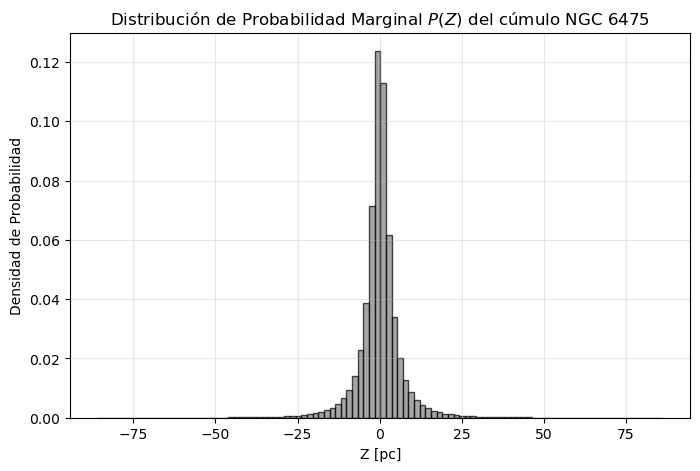

In [240]:
plt.figure(figsize=(8, 5))

Z_total = Z_matrix_valid_ngc_6475.flatten()

plt.hist(Z_total, bins=100, density=True, color='gray', alpha=0.7, edgecolor='black')
plt.title('Distribución de Probabilidad Marginal $P(Z)$ del cúmulo NGC 6475')
plt.xlabel('Z [pc]')
plt.ylabel('Densidad de Probabilidad')
plt.grid(True, alpha=0.3)
plt.show()

### Gráfica de Probabilidad Condicional $P(Z\ |\ X, Y)$

Se selecciona los índices de las estrellas en cada rango.

In [241]:
idx = [
    np.argmin(np.abs(Rs_valid_ngc_6475 - 0.1)),
    np.argmin(np.abs(Rs_valid_ngc_6475 - rc_ngc_6475)),
    np.argmin(np.abs(Rs_valid_ngc_6475 - rt_ngc_6475/2)),
    np.argmin(np.abs(Rs_valid_ngc_6475 - 0.95*rt_ngc_6475))
]

In [242]:
colors = ['blue', 'green', 'orange', 'red']
labels = [
    f'Estrella en Núcleo (R={Rs_valid_ngc_6475[idx[0]]:.2f} pc)',
    f'Estrella en $r_c$ (R={Rs_valid_ngc_6475[idx[1]]:.2f} pc)',
    f'Estrella en Intermedia (R={Rs_valid_ngc_6475[idx[2]]:.2f} pc)',
    f'Estrella en Borde (R={Rs_valid_ngc_6475[idx[3]]:.2f} pc)'
]

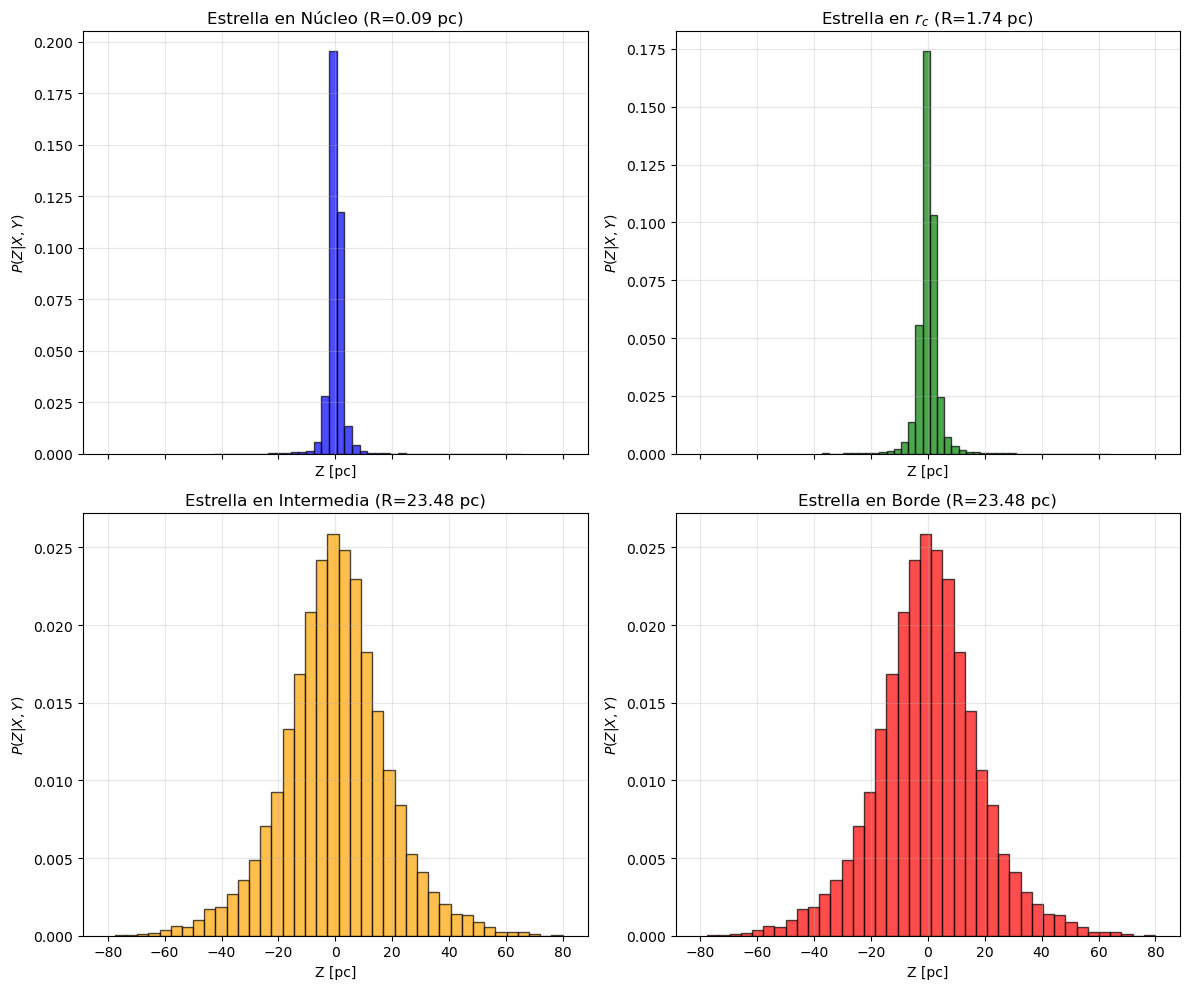

In [243]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axs = axs.flatten()

for i, idx_star in enumerate(idx):
    Z_star = Z_matrix_valid_ngc_6475[idx_star, :]
    
    axs[i].hist(Z_star, bins=40, density=True, color=colors[i], alpha=0.7, edgecolor='black')
    axs[i].set_title(labels[i])
    axs[i].set_xlabel('Z [pc]')
    axs[i].set_ylabel('$P(Z | X, Y)$')
    axs[i].grid(True, alpha=0.3)

    axs[i].set_xlim(-rt_ngc_6475, rt_ngc_6475)

plt.tight_layout()
plt.show()

## Análisis estadístico del cúmulo NGC 2437

Selección de miembros del cúmulo.

In [244]:
ngc_2437 = clusters[clusters['Name'] == 'NGC_2437']
ngc_2437_members = members[members['Name'] == 'NGC_2437']

Se seleccionan los valores de la declinación, ascensión recta y distancia al punto más denso del cúmulo y de los miembros de este.

In [245]:
ra0_ngc_2437 = ngc_2437['RA_ICRS'].values[0]
dec0_ngc_2437 = ngc_2437['DE_ICRS'].values[0]
d0_ngc_2437 = ngc_2437['dist50'].values[0]

ras_ngc_2437 = ngc_2437_members['RA_ICRS'].values
decs_ngc_2437 = ngc_2437_members['DE_ICRS'].values
ds_ngc_2437 = ngc_2437_members['r_med_photogeo'].values

Se calculan las distancias angulares y las distancias proyectadas en el plano.

In [246]:
ang_dist_ngc_2437 = angular_distances(ra0_ngc_2437, dec0_ngc_2437, ras_ngc_2437, decs_ngc_2437)
Rs_ngc_2437 = d0_ngc_2437 * np.tan(ang_dist_ngc_2437)

Se realiza el ajuste del perfil de densidad proyectada para encontrar $r_c$, $r_t$ y $k$.

In [247]:
rc_ngc_2437, rt_ngc_2437, k_ngc_2437 = fit_projected_density(Rs_ngc_2437)

Se realiza la proyección al plano tangente.

In [248]:
X_ngc_2437, Y_ngc_2437 = tangent_plane_projection(ras_ngc_2437, decs_ngc_2437, ra0_ngc_2437, dec0_ngc_2437, d0_ngc_2437)

Configuraciones de la simulación.

In [249]:
m_realization = 10000
N_stars = len(Rs_ngc_2437)

Se inicializa la matriz de N filas (estrellas) por m columnas (realizaciones).

In [250]:
Z_matrix_ngc_2437 = np.zeros((N_stars, m_realization))

Se calculan las m realizaciones de Monte Carlo.

In [251]:
for j in range(m_realization):
    Z_matrix_ngc_2437[:, j] = rejection_sampling(Rs_ngc_2437, rc_ngc_2437, rt_ngc_2437, k_ngc_2437)

Se filtran las estrellas que están dentro del radio de marea.

In [252]:
mask = Rs_ngc_2437 < rt_ngc_2437
Rs_valid_ngc_2437 = Rs_ngc_2437[mask]
Z_matrix_valid_ngc_2437 = Z_matrix_ngc_2437[mask, :]

### Gráficas de Probabilidad Marginal $P(Z)$ total

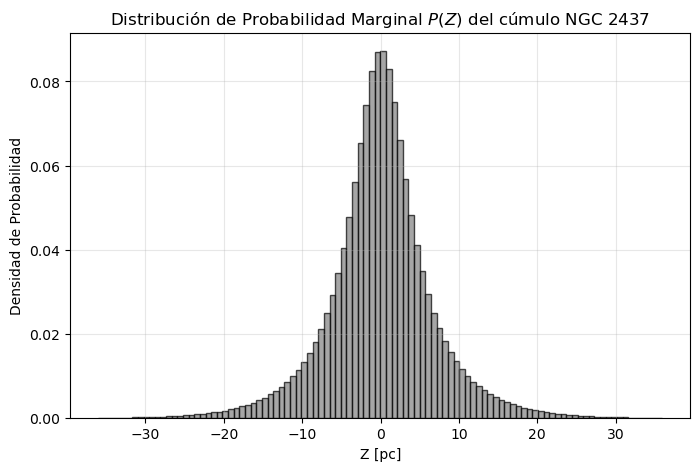

In [253]:
plt.figure(figsize=(8, 5))

Z_total = Z_matrix_valid_ngc_2437.flatten()

plt.hist(Z_total, bins=100, density=True, color='gray', alpha=0.7, edgecolor='black')
plt.title('Distribución de Probabilidad Marginal $P(Z)$ del cúmulo NGC 2437')
plt.xlabel('Z [pc]')
plt.ylabel('Densidad de Probabilidad')
plt.grid(True, alpha=0.3)
plt.show()

### Gráfica de Probabilidad Condicional $P(Z\ |\ X, Y)$

Se selecciona los índices de las estrellas en cada rango.

In [254]:
idx = [
    np.argmin(np.abs(Rs_valid_ngc_2437 - 0.1)),
    np.argmin(np.abs(Rs_valid_ngc_2437 - rc_ngc_2437)),
    np.argmin(np.abs(Rs_valid_ngc_2437 - rt_ngc_2437/2)),
    np.argmin(np.abs(Rs_valid_ngc_2437 - 0.95*rt_ngc_2437))
]

In [255]:
colors = ['blue', 'green', 'orange', 'red']
labels = [
    f'Estrella en Núcleo (R={Rs_valid_ngc_2437[idx[0]]:.2f} pc)',
    f'Estrella en $r_c$ (R={Rs_valid_ngc_2437[idx[1]]:.2f} pc)',
    f'Estrella en Intermedia (R={Rs_valid_ngc_2437[idx[2]]:.2f} pc)',
    f'Estrella en Borde (R={Rs_valid_ngc_2437[idx[3]]:.2f} pc)'
]

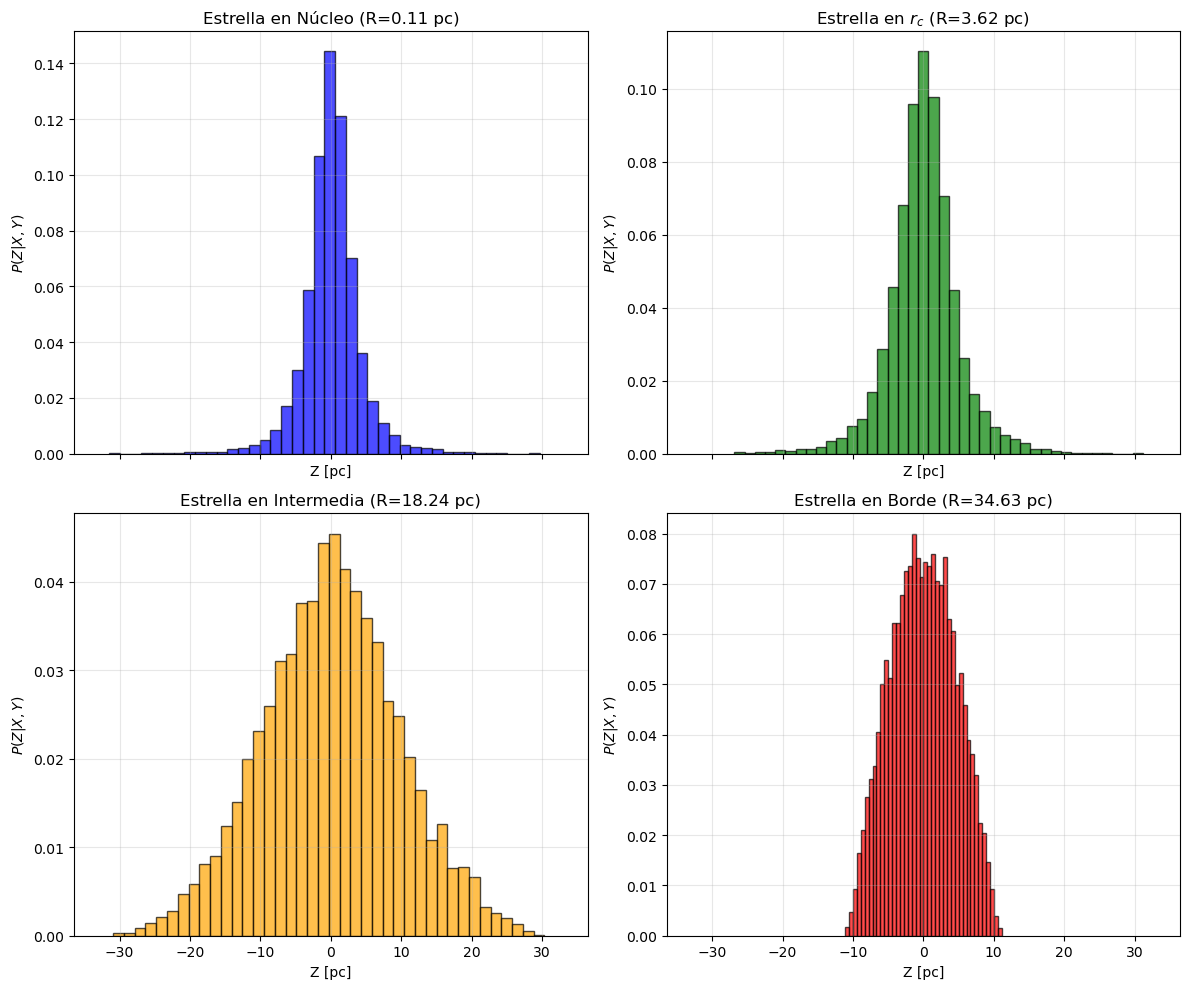

In [256]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axs = axs.flatten()

for i, idx_star in enumerate(idx):
    Z_star = Z_matrix_valid_ngc_2437[idx_star, :]
    
    axs[i].hist(Z_star, bins=40, density=True, color=colors[i], alpha=0.7, edgecolor='black')
    axs[i].set_title(labels[i])
    axs[i].set_xlabel('Z [pc]')
    axs[i].set_ylabel('$P(Z | X, Y)$')
    axs[i].grid(True, alpha=0.3)

    axs[i].set_xlim(-rt_ngc_2437, rt_ngc_2437)

plt.tight_layout()
plt.show()